In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

# Load in data

In [17]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)


# # # rename time as frame and adjust time to start from 1 instead of 0
# df['frame'] = df['time']
# df['time'] = df['frame'] + 1

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)
# max_time_stage1 = df.loc[df["stage"] == 1, "frame"].max()
# df["time_shifted"] = df["frame"] + ((df["stage"] == 2) * (max_time_stage1 + 1)) + 1

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 13.5 s, sys: 762 ms, total: 14.2 s
Wall time: 1min 17s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


In [18]:
df.columns

Index(['label', 'area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'bbox_area',
       'centroid-0', 'centroid-1', 'eccentricity', 'equivalent_diameter',
       'euler_number', 'extent', 'feret_diameter_max', 'filled_area',
       'inertia_tensor_eigvals-0', 'inertia_tensor_eigvals-1',
       'local_centroid-0', 'local_centroid-1', 'major_axis_length',
       'minor_axis_length', 'orientation', 'perimeter', 'perimeter_crofton',
       'solidity', 'Cy5_mean', 'Cy5_max', 'Cy5_min', 'centroid_x_px',
       'centroid_y_px', 'centroid_x_um', 'centroid_y_um', 'centroid_unit',
       'Cy5_sum', 'TaGFP_mean', 'TaGFP_max', 'TaGFP_min', 'TaGFP_sum',
       'mKate_mean', 'mKate_max', 'mKate_min', 'mKate_sum', 'time',
       'seg_channel_idx', 'seg_channel_name', 'basename', 'stage', 'condition',
       'scene', 'cell_id', 'time_shifted'],
      dtype='object')

In [19]:
start1 = df[df['stage'] == 1]['time'].min()
start2 = df[df['stage'] == 2]['time'].min()

end1 = df[df['stage'] == 1]['time'].max()
end2 = df[df['stage'] == 2]['time'].max()

total1 = (end1 - start1) + 1
total2 = (end2 - start2) + 1

print("CZI #1 (first 24 hours):")
print(f"Total frames = {total1}")
print(f"Total time = {total1 / 3:.2f} hours")
print(f"(start, end) frames = ({start1}, {end1})")

print("\nCZI #2 (last 48 hours):")
print(f"Total frames = {total2}")
print(f"Total time = {total2 / 3:.2f} hours")
print(f"(start, end) frames = ({start2}, {end2})")

CZI #1 (first 24 hours):
Total frames = 67
Total time = 22.33 hours
(start, end) frames = (0, 66)

CZI #2 (last 48 hours):
Total frames = 137
Total time = 45.67 hours
(start, end) frames = (0, 136)


# Cell counts

In [20]:
counts = (
    df.groupby(["time", "stage", "condition", "scene"])
      .size()
      .reset_index(name="n_cells")
)

# shift stage 2 times to follow after stage 1
max_time_stage1 = counts.loc[counts["stage"] == 1, "time"].max()
counts["time_shifted"] = counts["time"] + (
    (counts["stage"] == 2) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
counts['time_hours'] = counts['time_shifted'] / 3

# Get baseline counts (time=0) for each group
baseline = (
    counts.loc[counts["time"] == 0, ["stage", "condition", "scene", "n_cells"]]
    .rename(columns={"n_cells": "baseline_cells"})
)

counts = counts.merge(baseline, on=["stage", "condition", "scene"], how="left")

counts['n_cells_rel'] = counts['n_cells'] / counts['baseline_cells']
counts['n_cells_log2'] = np.log2(counts['n_cells_rel'])
counts['n_cells_abs'] = counts['n_cells'] - counts['baseline_cells']

print(counts.shape)
counts.head()

(2040, 11)


,time,stage,condition,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,hybrid,C3,615,0,0.0,615,1.0,0.0,0
4,0,1,hybrid,C4,768,0,0.0,768,1.0,0.0,0


In [10]:
# czi1_end = counts[counts['stage'] == 1]['time_hours'].max()
# czi1_start = counts[counts['stage'] == 1]['time_hours'].min()

# czi2_end = counts[counts['stage'] == 2]['time_hours'].max()
# czi2_start = counts[counts['stage'] == 2]['time_hours'].min()

# print(f'CZI #1 duration = {czi1_end - czi1_start} hours') 
# print(f'CZI #2 duration = {czi2_end - czi2_start:.2f} hours') 

CZI #1 duration = 22.0 hours
CZI #2 duration = 45.33 hours


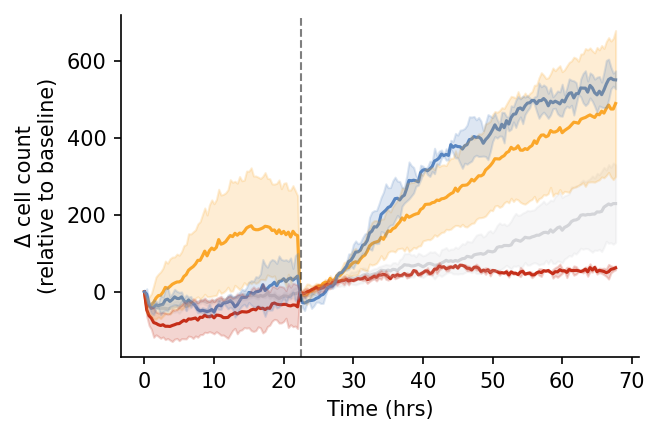

In [21]:
plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(4.5, 3))


cond_palette = {
    'control': '#D3D4D8',
    'hybrid': '#FBA72A',
    'mmMYOD1': '#C52E19',
    'siPRRX1': '#5785C1',
}

# conditions = ['Control', 'siPRRX1', 'siPRRX1/mmMYOD1', 'mmMYOD1']
# palette = ['#D3D4D8', '#5785C1', '#FBA72A', '#C52E19']

# summarized lineplot (mean ± 95% CI across scenes)
sns.lineplot(
    data=counts,
    x="time_hours",
    y='n_cells_abs',
    # y="n_cells_log2",
    hue="condition",
    palette=cond_palette,
    lw=1.5,
    errorbar="sd",  # mean ± 95% CI
    ax=ax,
    zorder=0,
    legend=False,
)

# stage transition line
plt.axvline(max_time_stage1/3 + 0.5, ls="--", c="k", lw=1, alpha=0.5, zorder=2)

plt.xlabel("Time (hrs)")
# plt.ylabel("Cell count (fold change)")
# plt.ylabel("Cell count")
plt.ylabel("Δ cell count\n(relative to baseline)")
# plt.ylabel("$log_2$(Δ cell count)")

sns.despine()
plt.tight_layout()
plt.show()

In [12]:
counts.head()

,time,stage,condition,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,hybrid,C3,615,0,0.0,615,1.0,0.0,0
4,0,1,hybrid,C4,768,0,0.0,768,1.0,0.0,0


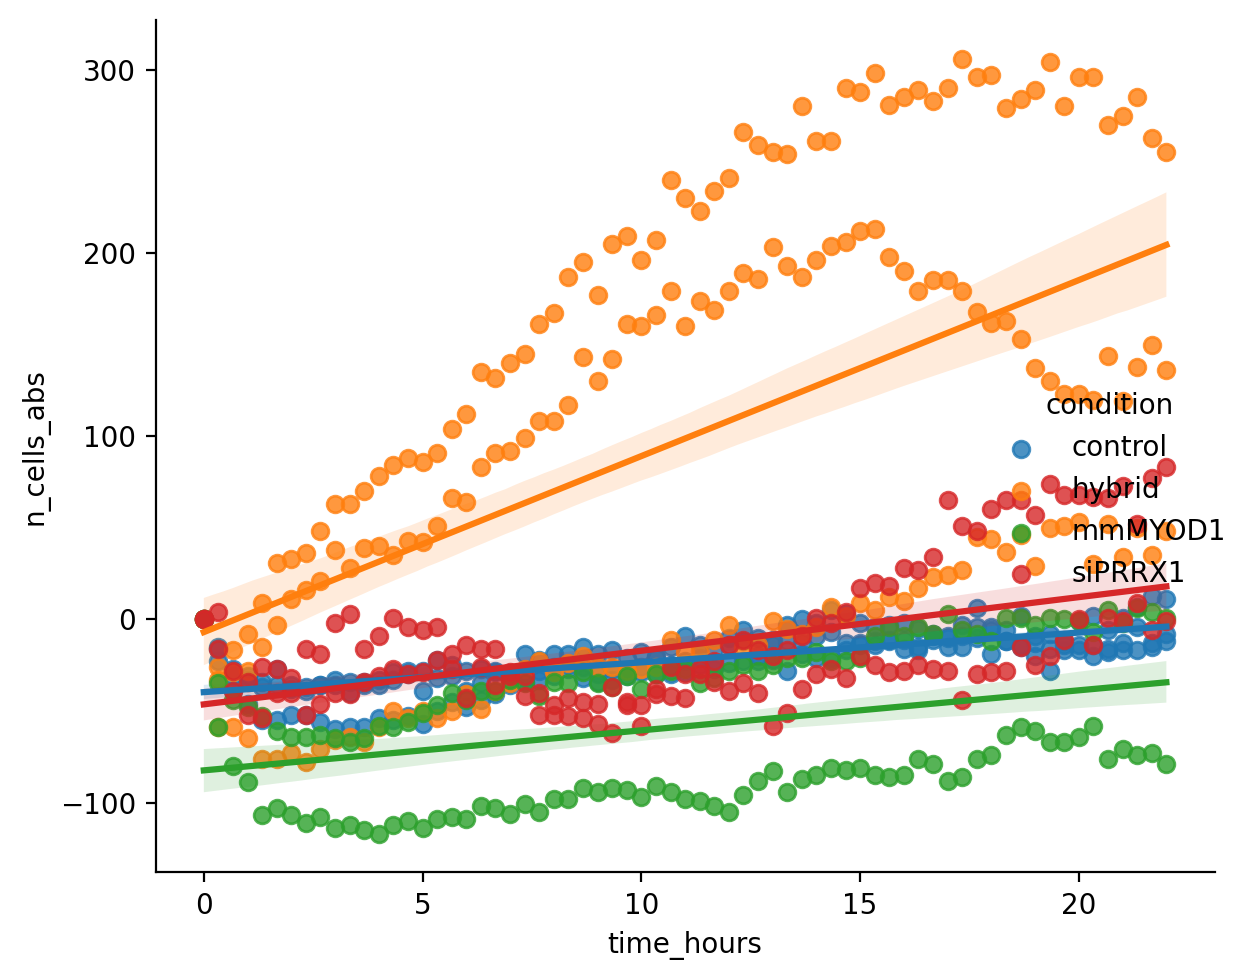

In [21]:
tmp = counts[counts['stage'] == 1].copy()

sns.lmplot(
    data=tmp,
    x='time_hours',
    y='n_cells_abs',
    hue='condition',
)

plt.tight_layout()
plt.show()

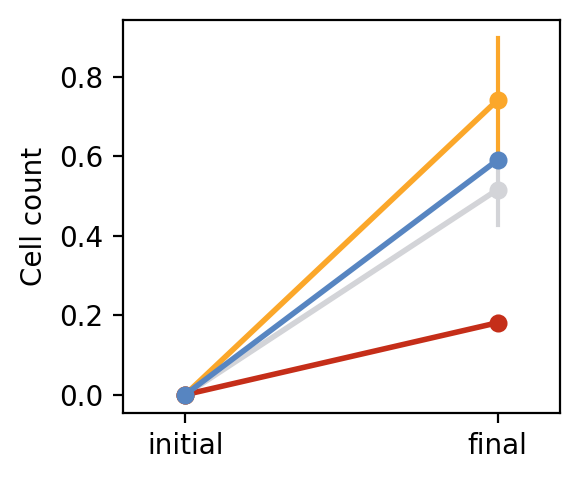

In [37]:
# get global initial and final counts per (condition, scene, stage)
cell_col = 'n_cells_log2'

endpoints = (
    counts.groupby(["condition", "scene", "stage"])
    .agg(initial=(cell_col, "first"), final=(cell_col, "last"))
    .reset_index()
)

endpoints.head()

endpoints_melt = endpoints.melt(
    id_vars=["condition", "scene", "stage"],
    value_vars=["initial", "final"],
    var_name="timepoint", value_name=cell_col
)

endpoints_melt.head()

stage = 2
endpoints_melt = endpoints_melt[endpoints_melt['stage'] == stage]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (3, 2.5)

# plot points
sns.pointplot(
    data=endpoints_melt,
    x="timepoint",
    y=cell_col,
    hue="condition",
    errorbar='se',
    lw=2,
    legend=False,
    palette=cond_palette,
    markersize=5,
    err_kws={"linewidth": 1.5},#, 'color': 'k'}
)

plt.margins(x=0.2)
plt.xlabel("")
plt.ylabel("Cell count")
plt.tight_layout()
plt.show()

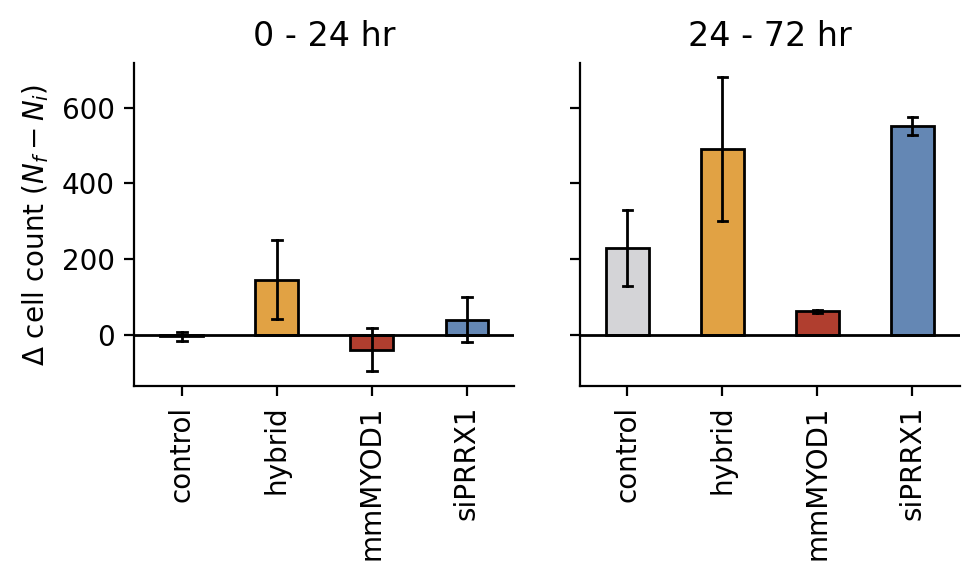

In [32]:
# compute net change in counts
endpoints["delta"] = endpoints["final"] - endpoints["initial"]

endpoints.head()

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

stages = sorted(endpoints['stage'].unique())

for i, stage in enumerate(stages):
    ax = axes[i]
    data = endpoints[endpoints["stage"] == stage]

    sns.barplot(
        data=data,
        x="condition",
        y="delta",
        hue="condition",
        width=0.45,
        ec='k',
        errorbar='sd',
        capsize=0.1,
        err_kws={"linewidth": 1, 'color':'k'},
        palette=cond_palette,
        ax=ax,
        legend=False 
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title("0 - 24 hr" if i == 0 else "24 - 72 hr")
    ax.set_xlabel("")
    ax.set_ylabel("Δ cell count ($N_f - N_i$)" if i == 0 else "")
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

plt.tight_layout(w_pad=2)
plt.show()

In [25]:
endpoints

,condition,scene,stage,initial,final,delta
0,control,B2,1,620,631,11
1,control,B2,2,557,799,242
2,control,C2,1,614,606,-8
3,control,C2,2,551,875,324
4,control,D2,1,495,483,-12
5,control,D2,2,432,555,123
6,hybrid,C3,1,615,751,136
7,hybrid,C3,2,645,1270,625
8,hybrid,C4,1,768,1023,255
9,hybrid,C4,2,768,1340,572


In stage 1, Control ~ mmMYOD1, and HYB ~ siPRRX1

In [22]:
df1 = df.copy()

stage1_ctrl_group = ['control', 'mmMYOD1'] # mmMYOD1 cells have been treated the same as control at this point

# groups into 2 conditions for stage 1, keeps all 4 for stage 2
# control = control + mmMYOD1
# siPRRX1 = siPRRX1 + HYB (as these cells have also been treated the same at this point)
df1['grouping_col'] = np.where(
    df1['stage'] == 1,
    np.where(
        df1['condition'].isin(stage1_ctrl_group),
        'control',
        'siPRRX1'
    ),
    df1['condition']
)

df1.head()

,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted,grouping_col
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67,siPRRX1
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67,siPRRX1
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67,siPRRX1
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67,siPRRX1
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67,siPRRX1


In [23]:
display(df1[df1['stage'] == 1]['grouping_col'].value_counts())
display(df1[df1['stage'] == 2]['grouping_col'].value_counts())

grouping_col
siPRRX1    321649
control    181078
Name: count, dtype: int64

grouping_col
hybrid     403301
siPRRX1    387066
control    251191
mmMYOD1    140701
Name: count, dtype: int64

In [24]:
counts = (
    df1.groupby(["time", "stage", "grouping_col", "scene"])
      .size()
      .reset_index(name="n_cells")
)

# shift stage 2 times to follow after stage 1
max_time_stage1 = counts.loc[counts["stage"] == 1, "time"].max()
counts["time_shifted"] = counts["time"] + (
    (counts["stage"] == 2) * (max_time_stage1 + 1)
)

# calculate hours (1 time point = 20 minutes)
counts['time_hours'] = counts['time_shifted'] / 3

# Get baseline counts (time=0) for each group
baseline = (
    counts.loc[counts["time"] == 0, ["stage", "grouping_col", "scene", "n_cells"]]
    .rename(columns={"n_cells": "baseline_cells"})
)

counts = counts.merge(baseline, on=["stage", "grouping_col", "scene"], how="left")

counts['n_cells_rel'] = counts['n_cells'] / counts['baseline_cells']
counts['n_cells_log2'] = np.log2(counts['n_cells_rel'])
counts['n_cells_abs'] = counts['n_cells'] - counts['baseline_cells']

print(counts.shape)
counts.head()

(2040, 11)


,time,stage,grouping_col,scene,n_cells,time_shifted,time_hours,baseline_cells,n_cells_rel,n_cells_log2,n_cells_abs
0,0,1,control,B2,620,0,0.0,620,1.0,0.0,0
1,0,1,control,C2,614,0,0.0,614,1.0,0.0,0
2,0,1,control,D2,495,0,0.0,495,1.0,0.0,0
3,0,1,control,D3,530,0,0.0,530,1.0,0.0,0
4,0,1,control,D4,626,0,0.0,626,1.0,0.0,0


In [52]:
counts[counts['stage'] == 1].groupby('grouping_col')['scene'].nunique()

grouping_col
control    5
siPRRX1    5
Name: scene, dtype: int64

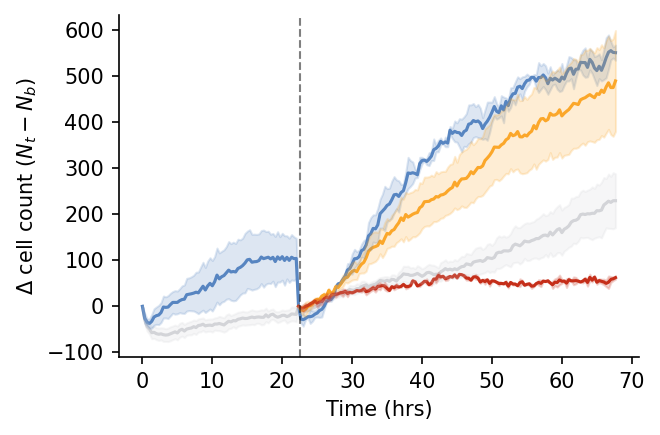

In [27]:
plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(4.5, 3))


cond_palette = {
    'control': '#D3D4D8',
    'hybrid': '#FBA72A',
    'mmMYOD1': '#C52E19',
    'siPRRX1': '#5785C1',
}


# summarized lineplot (mean ± 95% CI across scenes)
sns.lineplot(
    data=counts,
    x="time_hours",
    y='n_cells_abs',
    # y="n_cells_log2",
    hue="grouping_col",
    palette=cond_palette,
    lw=1.5,
    errorbar="se",  # mean ± 95% CI
    ax=ax,
    zorder=0,
    legend=False,
)

# stage transition line
plt.axvline(max_time_stage1/3 + 0.5, ls="--", c="k", lw=1, alpha=0.5, zorder=2)

plt.xlabel("Time (hrs)")
# plt.ylabel("Cell count (fold change)")
# plt.ylabel("Cell count")
plt.ylabel("Δ cell count ($N_t - N_b$)")
# plt.ylabel("$log_2$($N_t / N_b$)")

sns.despine()
plt.tight_layout()
plt.show()

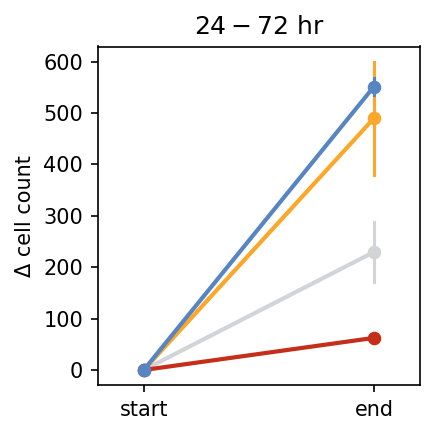

In [40]:
# get global initial and final counts per (condition, scene, stage)
cell_col = 'n_cells_abs'

endpoints = (
    counts.groupby(["grouping_col", "scene", "stage"])
    .agg(start=(cell_col, "first"), end=(cell_col, "last"))
    .reset_index()
)

endpoints.head()

endpoints_melt = endpoints.melt(
    id_vars=["grouping_col", "scene", "stage"],
    value_vars=["start", "end"],
    var_name="timepoint", value_name=cell_col
)

endpoints_melt.head()

stage = 2
endpoints_melt = endpoints_melt[endpoints_melt['stage'] == stage]

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (3, 3)

# plot points
sns.pointplot(
    data=endpoints_melt,
    x="timepoint",
    y=cell_col,
    hue="grouping_col",
    errorbar='se',
    lw=2,
    legend=False,
    palette=cond_palette,
    markersize=5,
    err_kws={"linewidth": 1.5},#, 'color': 'k'}
)

plt.margins(x=0.2)
plt.xlabel("")
# plt.ylabel("Cell count\n(relative to baseline)")
plt.ylabel("Δ cell count")

if stage == 2:
    plt.title("$24-72$ hr")
if stage == 1:
    plt.title("$0-24$ hr")

plt.tight_layout()
plt.show()

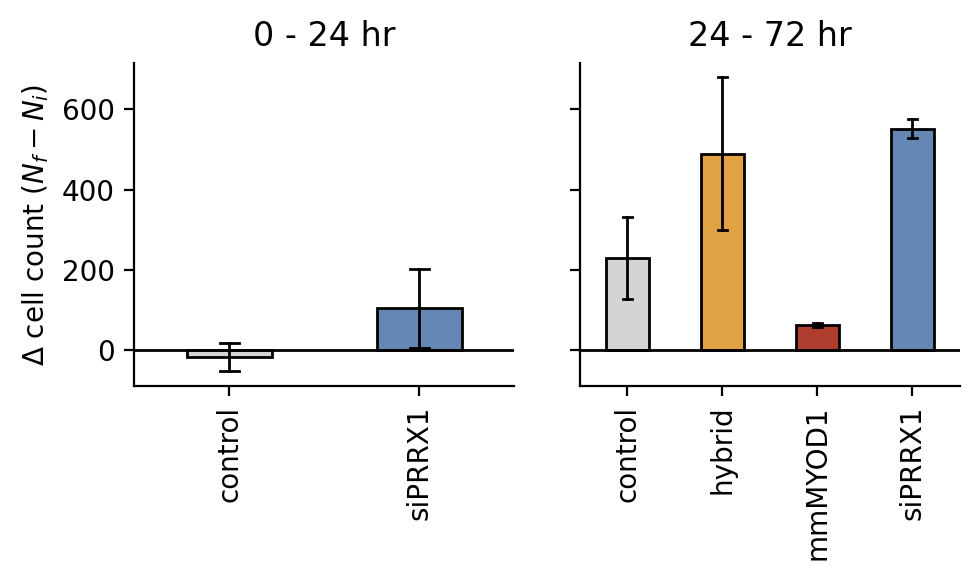

In [83]:
# compute net change in counts
endpoints["delta"] = endpoints["final"] - endpoints["initial"]

endpoints.head()

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

stages = sorted(endpoints['stage'].unique())

for i, stage in enumerate(stages):
    ax = axes[i]
    data = endpoints[endpoints["stage"] == stage]

    sns.barplot(
        data=data,
        x="grouping_col",
        y="delta",
        hue="grouping_col",
        width=0.45,
        ec='k',
        errorbar='sd',
        capsize=0.1,
        err_kws={"linewidth": 1, 'color':'k'},
        palette=cond_palette,
        ax=ax,
        legend=False 
    )
    ax.axhline(0, color="black", lw=1)
    ax.set_title("0 - 24 hr" if i == 0 else "24 - 72 hr")
    ax.set_xlabel("")
    ax.set_ylabel("Δ cell count ($N_f - N_i$)" if i == 0 else "")
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

plt.tight_layout(w_pad=2)
plt.show()

In [ ]:
# barplot at several timepoints

# t = [10, 20, 30, 40, 50, 60, 70]



# Tracks

In [41]:
%%time
### --- Tracking by stage ---
# Rename columns for trackpy
pdf = df.rename(columns={
    "time": "frame",
    "centroid_x_px": "x",
    "centroid_y_px": "y"
}).copy()

# Store all per-(cond,scene,stage) tracking results in a list
all_track_dfs = []

for (cond, scene, stage), g in pdf.groupby(["condition", "scene", "stage"]):
    print(f"Tracking: {(cond, scene, stage)}")
    g_sorted = g.sort_values("frame")
    
    # Run tracking
    linked = tp.link_df(
        g_sorted,
        search_range=55,        # adjust as needed
        memory=5,
        adaptive_stop=True
    )
    
    # Add context columns
    linked["condition"] = cond
    linked["scene"] = scene
    linked["stage"] = stage
    
    # Optionally filter out short tracks (e.g., less than 50 frames)
    linked = tp.filter_stubs(linked, threshold=10)
    
    print(f"\tlinked.shape: {linked.shape}")
    
    all_track_dfs.append(linked)

# Combine all per-stage results
all_traj = pd.concat(all_track_dfs, ignore_index=True)
print(f"All tracked data shape: {all_traj.shape}")

Frame 136: 1690 trajectories present.
	linked.shape: (194021, 52)
All tracked data shape: (1633220, 52)
CPU times: user 49 s, sys: 2.79 s, total: 51.8 s
Wall time: 56.7 s


In [42]:
all_traj['particle_id'] = all_traj['stage'].astype(str) + '_' + all_traj['condition'] + '_' + all_traj['scene'] + '_' + all_traj['particle'].astype(str)

columns_to_keep = [
    'condition', 'scene', 'stage', 'particle', 'particle_id', 'frame', 'time_shifted',
    'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean', 'x', 'y',
]

all_traj = all_traj[columns_to_keep]

all_traj.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647
1,control,B2,1,2,1_control_B2_2,0,0,107.0,0.094927,0.234181,0.180446,232.588785,2579.112150
2,control,B2,1,3,1_control_B2_3,0,0,118.0,0.037478,0.136275,0.193143,616.525424,551.245763
3,control,B2,1,4,1_control_B2_4,0,0,157.0,0.040521,0.247596,0.201448,1693.929936,2509.847134
4,control,B2,1,5,1_control_B2_5,0,0,86.0,0.107119,0.047916,0.010504,2243.581395,2229.174419


In [43]:
# calculate total trajectory length per cell
all_traj['path_length'] = all_traj.groupby('particle_id')['frame'].transform(lambda x: x.nunique())



tdf = all_traj.copy()
print(f"N cells: {tdf['particle_id'].nunique()}")

min_path_length = 50

# remove short trajectories
tdf = tdf[tdf['path_length'] >= min_path_length]
print(f"N cells with at least 50 frames: {tdf['particle_id'].nunique()}\n")

# assess trajectory gaps
tdf = tdf.sort_values(['particle_id', 'frame'])

tdf['frame_diff'] = tdf.groupby('particle_id')['frame'].diff()

# Find gaps (diff > 1)
tdf['gap_length'] = tdf['frame_diff'] - 1
tdf['gap_length'] = tdf['gap_length'].where(tdf['gap_length'] > 0, 0)  # set negative/0 diffs to 0

gap_info = tdf.groupby('particle_id')['gap_length'].agg([
    ('has_gap', lambda x: x.gt(0).any()),
    ('max_gap_length', 'max')
]).reset_index()

# Merge flag and gap info back to the original dataframe
tdf = tdf.merge(gap_info, on='particle_id')
tdf = tdf.drop(columns=['frame_diff'])

print(f"{tdf.drop_duplicates('particle_id')['has_gap'].value_counts()}\n")

tdf.drop_duplicates('particle_id').groupby('condition')['max_gap_length'].describe()

N cells: 27824
N cells with at least 50 frames: 15068

has_gap
False    8941
True     6127
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
control,3366.0,0.624777,1.321116,0.0,0.0,0.0,0.0,5.0
hybrid,4908.0,1.305420,1.655664,0.0,0.0,0.0,2.0,5.0
mmMYOD1,1957.0,0.761369,1.405794,0.0,0.0,0.0,1.0,5.0
siPRRX1,4837.0,1.330784,1.703688,0.0,0.0,0.0,3.0,5.0


In [44]:
tdf.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0


In [64]:
tdf.groupby(['condition', 'scene']).nunique()

stage  particle  particle_id  frame  time_shifted  \
condition scene                                                      
control   B2         2       842         1212    137           204   
          C2         2       860         1247    137           204   
          D2         2       603          907    137           204   
hybrid    C3         2      1283         1518    137           204   
          C4         2      1421         1758    137           204   
          C6         2      1188         1632    137           204   
mmMYOD1   D3         2       678          961    137           204   
          D4         2       752          996    137           204   
siPRRX1   B3         2      1761         2271    137           204   
          B4         2      1947         2566    137           204   

                 filled_area  Cy5_mean  TaGFP_mean  mKate_mean       x  \
condition scene                                                          
control   B2             584    105154      108186       84915  107955   
          C2             563    107189      110689       95474  110650   
          D2             815     80073       81583       73666   81791   
hybrid    C3             679    119812      121322      105414  122715   
          C4             674    143314      144523      130927  147601   
          C6             621    141018      143894      126135  144732   
mmMYOD1   D3             671     82825       83880       71741   84104   
          D4             791     85224       86262       70452   86745   
siPRRX1   B3             727    180851      187691      174517  189959   
          B4             728    208321      214324      202995  216201   

                      y  path_length  gap_length  has_gap  max_gap_length  
condition scene                                                            
control   B2     108022           87           6        2               6  
          C2     110651           88           6        2               6  
          D2      81763           85           6        2               6  
hybrid    C3     122609           88           6        2               6  
          C4     147492           88           6        2               6  
          C6     144656           88           6        2               6  
mmMYOD1   D3      84065           86           6        2               6  
          D4      86664           85           6        2               6  
siPRRX1   B3     189847           88           6        2               6  
          B4     215772           88           6        2               6

In [45]:
from sklearn import preprocessing

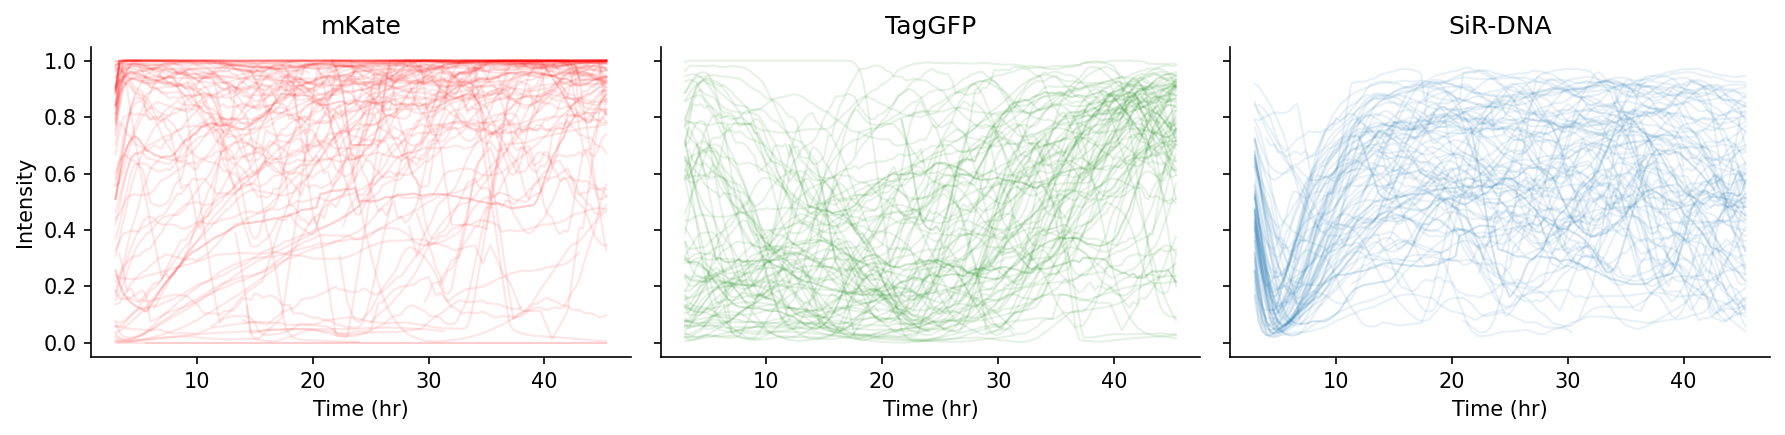

In [66]:
n_sample = 100
smooth = 10 # in frames
minsPerFrame = 20
# maxTime = 32 # in hours
# timeFilter = (maxTime *  60) / minsPerFrame # first 72 timepoints == 24 hours
# minTrack = 11 # in hours
# trackFilter = (minTrack *  60) / minsPerFrame

# print(f"Minutes per Frame: {minsPerFrame}")
# print(f"Max Time: {maxTime}hrs ({int(timeFilter)} frames)")
# print(f"Min Track: {minTrack}hrs ({int(trackFilter)} frames)")

# filter the data
stage = 2
well = 'B2'

pdf = tdf[(tdf['stage'] == stage) & (tdf['scene'] == well)].copy()
pdf['Time'] = (pdf['frame'] * minsPerFrame) / 60

rids = np.random.choice(pdf['particle_id'], n_sample)

# pdf = tdf.copy()
# pdf = pdf[pdf['t'] < timeFilter]
# pdf['Time'] = (pdf['t'] * minsPerFrame) / 60
# pdf['trackLength'] = pdf.groupby('ID')['x'].count()

# longTracks = pdf[pdf['trackLength'] > trackFilter]
# rids = np.random.choice(longTracks.index, n_sample)


c1 = 'mKate_mean'
c2 = 'TaGFP_mean'
c3 = 'Cy5_mean'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 12, 3
fig, ax = plt.subplots(1, 3, sharey=True)


for rid in rids:
    idf = pdf[pdf['particle_id'] == rid].reset_index(drop=True)
    
    min_max_scaler = preprocessing.MinMaxScaler()
    
    # normalize
    idf['c1'] = min_max_scaler.fit_transform(idf[c1].to_numpy().reshape(-1, 1))
    idf['c2'] = min_max_scaler.fit_transform(idf[c2].to_numpy().reshape(-1, 1))
    idf['c3'] = min_max_scaler.fit_transform(idf[c3].to_numpy().reshape(-1, 1))
    idf['A'] = min_max_scaler.fit_transform(idf['filled_area'].to_numpy().reshape(-1, 1))
    
    # smooth
    idf['c1'] = idf['c1'].rolling(smooth).mean()
    idf['c2'] = idf['c2'].rolling(smooth).mean()
    idf['c3'] = idf['c3'].rolling(smooth).mean()
    
    idf['A'] = idf['A'].rolling(smooth).mean()

    ax[0].plot(idf['Time'], idf['c1'], c='r', lw=1, alpha=0.1)
    ax[1].plot(idf['Time'], idf['c2'], c='g', lw=1, alpha=0.1)
    ax[2].plot(idf['Time'], idf['c3'], c='C0', lw=1, alpha=0.1)

    ax[0].set_xlabel('Time (hr)')
    ax[0].set_ylabel('Intensity')
    ax[1].set_xlabel('Time (hr)')
    ax[2].set_xlabel('Time (hr)')

    ax[0].set_title('mKate')
    ax[1].set_title('TagGFP')
    ax[2].set_title('SiR-DNA')

sns.despine()
plt.tight_layout()
plt.show()

In [49]:
tdf.head()

,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0


In [67]:
## ALL CELLS
test_df = tdf.copy()
print(f"N cells: {test_df['particle_id'].nunique()}")

# # Normalize (min-max)
# red_max = test_df['mKate_mean'].max()
# green_max = test_df['TaGFP_mean'].max()
# print(f"\nmKate global max: {red_max:.3f}")
# print(f"TaGFP global max: {green_max:.3f}")

# red_q95 = test_df['mKate_mean'].quantile(0.95)
# green_q95 = test_df['TaGFP_mean'].quantile(0.95)
# print(f"mKate 95%: {red_q95:.3f}")
# print(f"TaGFP 95%: {green_q95:.3f}")

# red_min = test_df['mKate_mean'].min()
# green_min = test_df['TaGFP_mean'].min()
# print(f"\nmKate global min: {red_min:.3f}")
# print(f"TaGFP global min: {green_min:.3f}")

# red_q5 = test_df['mKate_mean'].quantile(0.05)
# green_q5 = test_df['TaGFP_mean'].quantile(0.05)
# print(f"mKate 5%: {red_q5:.3f}")
# print(f"TaGFP 5%: {green_q5:.3f}")


# # Global normalization for each reporter
# test_df['TaGFP_norm'] = (test_df['TaGFP_mean'] - green_min) / (green_max - green_min)
# test_df['mKate_norm'] = (test_df['mKate_mean'] - red_min) / (red_max - red_min)
# test_df['Cy5_norm'] = (test_df['Cy5_mean'] - test_df['Cy5_mean'].min()) / (test_df['Cy5_mean'].max() - test_df['Cy5_mean'].min())

# Global normalization for each reporter (by stage)
green_min = test_df.groupby("stage")["TaGFP_mean"].transform("min")
green_max = test_df.groupby("stage")["TaGFP_mean"].transform("max")

red_min = test_df.groupby("stage")["mKate_mean"].transform("min")
red_max = test_df.groupby("stage")["mKate_mean"].transform("max")

cy5_min = test_df.groupby("stage")["Cy5_mean"].transform("min")
cy5_max = test_df.groupby("stage")["Cy5_mean"].transform("max")

# 2. Perform the normalization using the stage-specific boundaries
test_df["TaGFP_norm"] = (test_df["TaGFP_mean"] - green_min) / (
    green_max - green_min
)
test_df["mKate_norm"] = (test_df["mKate_mean"] - red_min) / (red_max - red_min)
test_df["Cy5_norm"] = (test_df["Cy5_mean"] - cy5_min) / (cy5_max - cy5_min)



print(test_df.shape)
test_df.head()

N cells: 15068
(1300948, 20)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,0.0,False,0.0,0.551797,0.972781,0.058496
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,0.0,False,0.0,0.533058,0.970838,0.175343
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,0.0,False,0.0,0.507353,0.954420,0.312970
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,0.0,False,0.0,0.498645,0.932851,0.474235
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,0.0,False,0.0,0.496974,0.932718,0.623611


In [56]:
# %%time

# red = 'mKate_norm'
# green = 'TaGFP_norm'
# jump_thresh = 0.5
# max_allowed_jumps = 2

# df = test_df.copy()

# # --- Compute per-row differences, grouped by cell ---
# df['red_diff'] = df.groupby('particle_id')[red].diff().abs()
# df['green_diff'] = df.groupby('particle_id')[green].diff().abs()

# # --- Flag "big jumps" ---
# df['red_big_jump'] = df['red_diff'] > jump_thresh
# df['green_big_jump'] = df['green_diff'] > jump_thresh

# # --- Aggregate per-cell (particle_id): count of big jumps ---
# jump_counts = (
#     df.groupby('particle_id')[['red_big_jump', 'green_big_jump']].sum()
#     .rename(columns={'red_big_jump': 'red_big_jump_count', 'green_big_jump': 'green_big_jump_count'})
# )

# # --- Flag noisy cells at the cell (particle) level ---
# jump_counts['noisy'] = (jump_counts['red_big_jump_count'] > max_allowed_jumps) | \
#                        (jump_counts['green_big_jump_count'] > max_allowed_jumps)

# # --- Merge/noisy to df, then broadcast to all rows for each cell ---
# noisy_map = jump_counts['noisy']
# df['noisy'] = df['particle_id'].map(noisy_map)

# # Optional: Clean up helper cols
# df.drop(['red_diff', 'green_diff', 'red_big_jump', 'green_big_jump'], axis=1, inplace=True)
# df.head()


# df = df[~df['noisy']]
# print(f"N cells after dropping noisy cells: {df['particle_id'].nunique()}")

N cells after dropping noisy cells: 14249
CPU times: user 1.44 s, sys: 218 ms, total: 1.66 s
Wall time: 1.69 s


In [68]:
%%time
def smooth_reporters_group(g, red_col='mKate_norm', green_col='TaGFP_norm', nuc_col='Cy5_norm', window_length=7, polyorder=2):
    g = g.copy()  # Don't modify in-place.
    n = len(g)
    # Must have enough points for filter
    good_len = min(n, window_length if n % 2 == 1 else window_length - 1)
    if good_len < 3:
        g[red_col + '_smooth'] = g[red_col]
        g[green_col + '_smooth'] = g[green_col]
        g[nuc_col + '_smooth'] = g[nuc_col]
    else:
        g = g.sort_values('frame')  # ensure frame order
        g[red_col + '_smooth'] = savgol_filter(g[red_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[green_col + '_smooth'] = savgol_filter(g[green_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[nuc_col + '_smooth'] = savgol_filter(g[nuc_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
    return g

# Use groupby.apply for speed and auto-concatenation
test_df = test_df.groupby('particle_id', group_keys=False).apply(
    smooth_reporters_group, 
    red_col='mKate_norm', 
    green_col='TaGFP_norm', 
    nuc_col='Cy5_norm',
    window_length=9, 
    polyorder=2
)

test_df.head()

CPU times: user 36 s, sys: 552 ms, total: 36.5 s
Wall time: 37.7 s


<timed exec>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,path_length,gap_length,has_gap,max_gap_length,TaGFP_norm,mKate_norm,Cy5_norm,mKate_norm_smooth,TaGFP_norm_smooth,Cy5_norm_smooth
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,...,67,0.0,False,0.0,0.551797,0.972781,0.058496,0.966301,0.543242,0.009032
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,...,67,0.0,False,0.0,0.533058,0.970838,0.175343,0.963199,0.530676,0.196675
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,...,67,0.0,False,0.0,0.507353,0.954420,0.312970,0.959880,0.519914,0.363017
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,...,67,0.0,False,0.0,0.498645,0.932851,0.474235,0.956343,0.510956,0.508058
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,...,67,0.0,False,0.0,0.496974,0.932718,0.623611,0.952588,0.503803,0.631797


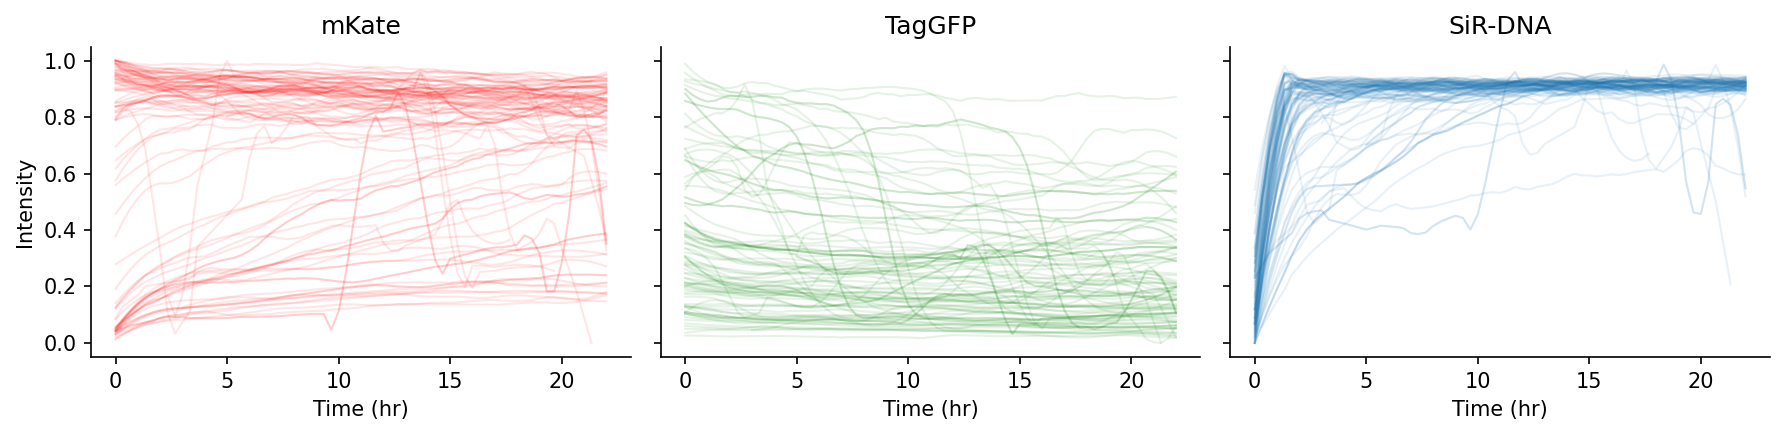

In [69]:
n_sample = 100
minsPerFrame = 20

# filter the data
stage = 1
well = 'B2'

pdf = test_df[(test_df['stage'] == stage) & (test_df['scene'] == well)].copy()
pdf['Time'] = (pdf['frame'] * minsPerFrame) / 60

rids = np.random.choice(pdf['particle_id'], n_sample)



c1 = 'mKate_norm_smooth'
c2 = 'TaGFP_norm_smooth'
c3 = 'Cy5_norm_smooth'

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 12, 3
fig, ax = plt.subplots(1, 3, sharey=True)


for rid in rids:
    idf = pdf[pdf['particle_id'] == rid].reset_index(drop=True)

    ax[0].plot(idf['Time'], idf[c1], c='r', lw=1, alpha=0.1)
    ax[1].plot(idf['Time'], idf[c2], c='g', lw=1, alpha=0.1)
    ax[2].plot(idf['Time'], idf[c3], c='C0', lw=1, alpha=0.1)

    ax[0].set_xlabel('Time (hr)')
    ax[0].set_ylabel('Intensity')
    ax[1].set_xlabel('Time (hr)')
    ax[2].set_xlabel('Time (hr)')

    ax[0].set_title('mKate')
    ax[1].set_title('TagGFP')
    ax[2].set_title('SiR-DNA')

sns.despine()
plt.tight_layout()
plt.show()

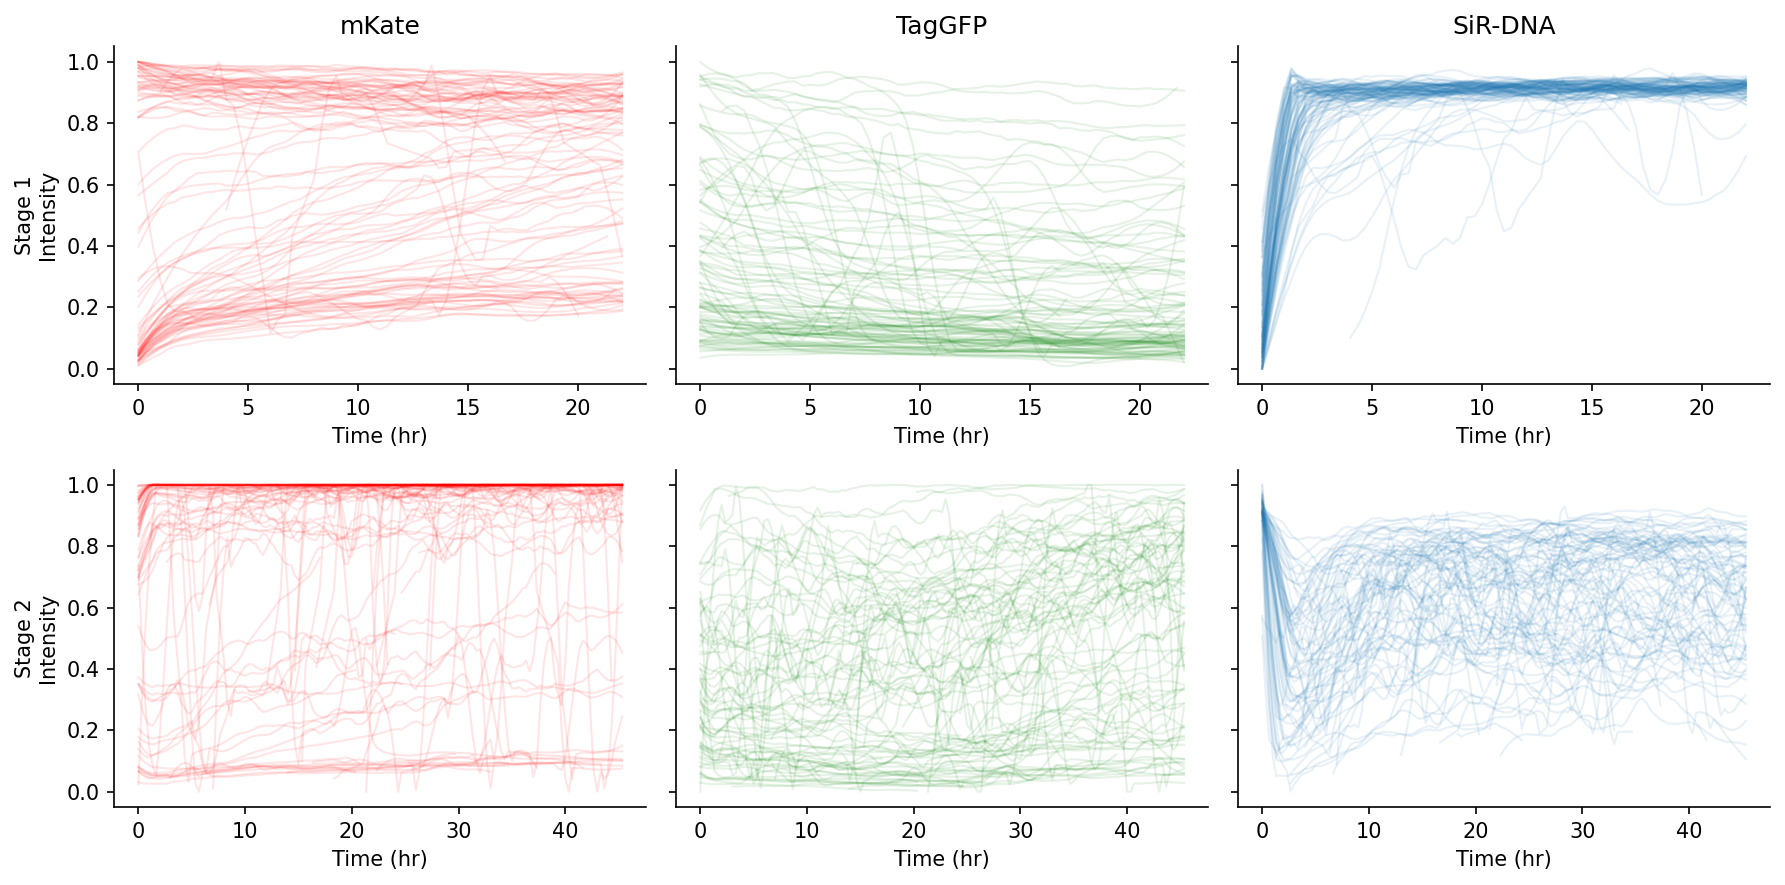

In [70]:
n_sample = 100
minsPerFrame = 20
well = "B2"  # Keep the well constant across both stages

c1 = "mKate_norm_smooth"
c2 = "TaGFP_norm_smooth"
c3 = "Cy5_norm_smooth"

# Define the two stages
stages = [1, 2]

plt.rcParams["figure.dpi"] = 150
# Increased height to 6 to comfortably fit two rows
plt.rcParams["figure.figsize"] = 12, 6

# Create a 2x3 subplot grid
fig, axes = plt.subplots(2, 3, sharey=True, sharex=False)

# Loop through each stage (row_idx will be 0 for Stage 1, 1 for Stage 2)
for row_idx, stage in enumerate(stages):

    # 1. Filter the data for the specific stage and well
    pdf = test_df[(test_df["stage"] == stage) & (test_df["scene"] == well)].copy()

    # Prevent errors if a stage/well combination is empty
    if pdf.empty:
        print(f"Warning: No data found for Stage {stage}, Well {well}")
        continue

    pdf["Time"] = (pdf["frame"] * minsPerFrame) / 60

    # Get random particle IDs for this specific stage
    available_particles = pdf["particle_id"].unique()
    actual_sample = min(n_sample, len(available_particles))
    rids = np.random.choice(available_particles, actual_sample, replace=False)

    # 2. Plot the individual particle trajectories
    for rid in rids:
        idf = pdf[pdf["particle_id"] == rid]

        axes[row_idx, 0].plot(idf["Time"], idf[c1], c="r", lw=1, alpha=0.1)
        axes[row_idx, 1].plot(idf["Time"], idf[c2], c="g", lw=1, alpha=0.1)
        axes[row_idx, 2].plot(idf["Time"], idf[c3], c="C0", lw=1, alpha=0.1)

    # 3. Set labels and titles (Done once per row instead of per particle)
    axes[row_idx, 0].set_ylabel(f"Stage {stage}\nIntensity")

    for col_idx in range(3):
        axes[row_idx, col_idx].set_xlabel("Time (hr)")

    # Only set titles on the top row to avoid clutter
    if row_idx == 0:
        axes[0, 0].set_title("mKate")
        axes[0, 1].set_title("TagGFP")
        axes[0, 2].set_title("SiR-DNA")

sns.despine()
plt.tight_layout()
plt.show()